# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan
## Analisis Data Siswa dan Prediksi Dropout


### 1. Business Understanding

#### Latar Belakang
Jaya Jaya Institut merupakan salah satu institusi pendidikan perguruan yang telah berdiri sejak tahun 2000. Hingga saat ini ia telah mencetak banyak lulusan dengan reputasi yang sangat baik. Akan tetapi, terdapat banyak juga siswa yang tidak menyelesaikan pendidikannya alias dropout.

Jumlah dropout yang tinggi ini tentunya menjadi salah satu masalah yang besar untuk sebuah institusi pendidikan. Oleh karena itu, Jaya Jaya Institut ingin mendeteksi secepat mungkin siswa yang mungkin akan melakukan dropout sehingga dapat diberi bimbingan khusus.

#### Permasalahan Bisnis
1. Bagaimana mengidentifikasi siswa yang berisiko tinggi melakukan dropout?
2. Faktor-faktor apa saja yang paling berpengaruh terhadap dropout siswa?
3. Bagaimana membuat sistem prediksi yang akurat untuk mendeteksi siswa yang berisiko dropout?

#### Tujuan
1. Menganalisis faktor-faktor yang mempengaruhi dropout siswa
2. Membuat model machine learning untuk memprediksi siswa yang berisiko dropout
3. Membuat dashboard untuk memonitor performa siswa secara real-time


### 2. Data Understanding

Dataset yang digunakan adalah Students Performance Dataset dari Dicoding Academy yang berisi informasi tentang 4,424 siswa perguruan tinggi.
Kita akan menggunakan dua file dataset:
1. `students_performance.csv` (Dataset Mentah / Raw Data)
2. `students_performance_processed.csv` (Dataset yang sudah diproses untuk permodelan)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Set visualisasi
plt.style.use('default')
sns.set_palette('Set2')
%matplotlib inline

In [2]:
# Load raw dataset untuk Exploratory Data Analysis (EDA)
df_raw = pd.read_csv('students_performance.csv', sep=';')

print(f'Jumlah baris: {df_raw.shape[0]}')
print(f'Jumlah kolom: {df_raw.shape[1]}')
df_raw.head()

Jumlah baris: 4424
Jumlah kolom: 37


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
# Informasi dataset mentah
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [4]:
# Distribusi Status pada data mentah
print('Distribusi Status:')
print(df_raw['Status'].value_counts())
print('\nPersentase Status:')
print(df_raw['Status'].value_counts(normalize=True) * 100)

Distribusi Status:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Persentase Status:
Status
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


### 3. Data Preparation & Model Development

Kita akan memuat dataset yang sudah diproses (`students_performance_processed.csv`) yang telah melalui tahapan Label Encoding pada fitur kategorikal. Dataset ini siap digunakan untuk permodelan.


In [5]:
# Load processed dataset untuk Machine Learning
df_processed = pd.read_csv('students_performance_processed.csv')

print(f'Jumlah baris: {df_processed.shape[0]}')
print(f'Jumlah kolom: {df_processed.shape[1]}')
df_processed.head()

Jumlah baris: 4424
Jumlah kolom: 55


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Fathers_qualification_encoded,Mothers_occupation_encoded,Fathers_occupation_encoded,Displaced_encoded,Educational_special_needs_encoded,Debtor_encoded,Tuition_fees_up_to_date_encoded,Gender_encoded,Scholarship_holder_encoded,International_encoded
0,1,17,5,171,1,1,122.0,1,19,12,...,3,25,43,1,0,0,1,1,0,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,15,23,37,1,0,0,0,1,0,0
2,1,1,5,9070,1,1,122.0,1,37,37,...,22,29,43,1,0,0,0,1,0,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,22,25,37,1,0,0,1,0,0,0
4,2,39,1,8014,0,1,100.0,1,37,38,...,23,29,43,0,0,0,1,0,0,0


In [6]:
# Define features (X) dan target (y)
# Kolom-kolom yang berakhiran '_encoded' dan beberapa kolom numerik
feature_cols = [col for col in df_processed.columns if col.endswith('_encoded') and col != 'Status_encoded']
numeric_features = ['Admission_grade', 'Age_at_enrollment', 'Curricular_units_1st_sem_credited',
                    'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations',
                    'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
                    'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited',
                    'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations',
                    'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
                    'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate',
                    'Inflation_rate', 'GDP']

all_features = feature_cols + numeric_features
X = df_processed[all_features]
y = df_processed['Status_encoded'] # 0: Dropout, 1: Enrolled, 2: Graduate

print(f'Jumlah Features: {X.shape[1]}')
print(f'Kelas target: {y.unique()}')
X.head()

Jumlah Features: 34
Kelas target: [0 2 1]


,Marital_status_encoded,Application_mode_encoded,Course_encoded,Daytime_evening_attendance_encoded,Previous_qualification_encoded,Nacionality_encoded,Mothers_qualification_encoded,Fathers_qualification_encoded,Mothers_occupation_encoded,Fathers_occupation_encoded,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
0,0,4,0,1,0,0,6,3,25,43,...,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,0,2,10,1,0,0,0,15,23,37,...,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,0,0,4,1,0,0,17,22,29,43,...,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,0,4,14,1,0,0,18,22,25,37,...,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,1,9,2,0,0,0,17,23,29,43,...,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79


In [7]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train size: {X_train.shape[0]}')
print(f'Test size: {X_test.shape[0]}')
print(f'Class distribution in train:')
print(y_train.value_counts())

Train size: 3539
Test size: 885
Class distribution in train:
Status_encoded
2    1767
0    1137
1     635
Name: count, dtype: int64


In [8]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Features scaled successfully')

Features scaled successfully


In [9]:
# Train model
model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)
print('Model trained successfully')

Model trained successfully


In [10]:
# Predict
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Dropout', 'Enrolled', 'Graduate']))

Accuracy: 0.7740

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.81      0.75      0.78       284
    Enrolled       0.59      0.36      0.45       159
    Graduate       0.79      0.94      0.86       442

    accuracy                           0.77       885
   macro avg       0.73      0.68      0.69       885
weighted avg       0.76      0.77      0.76       885



In [11]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': all_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print('Top 10 Features:')
print(feature_importance.head(10))

Top 10 Features:
                                 feature  importance
28     Curricular_units_2nd_sem_approved    0.114567
29        Curricular_units_2nd_sem_grade    0.098085
22     Curricular_units_1st_sem_approved    0.072564
23        Curricular_units_1st_sem_grade    0.070791
17                       Admission_grade    0.053592
27  Curricular_units_2nd_sem_evaluations    0.050619
18                     Age_at_enrollment    0.046999
21  Curricular_units_1st_sem_evaluations    0.044737
13       Tuition_fees_up_to_date_encoded    0.038783
9             Fathers_occupation_encoded    0.035714


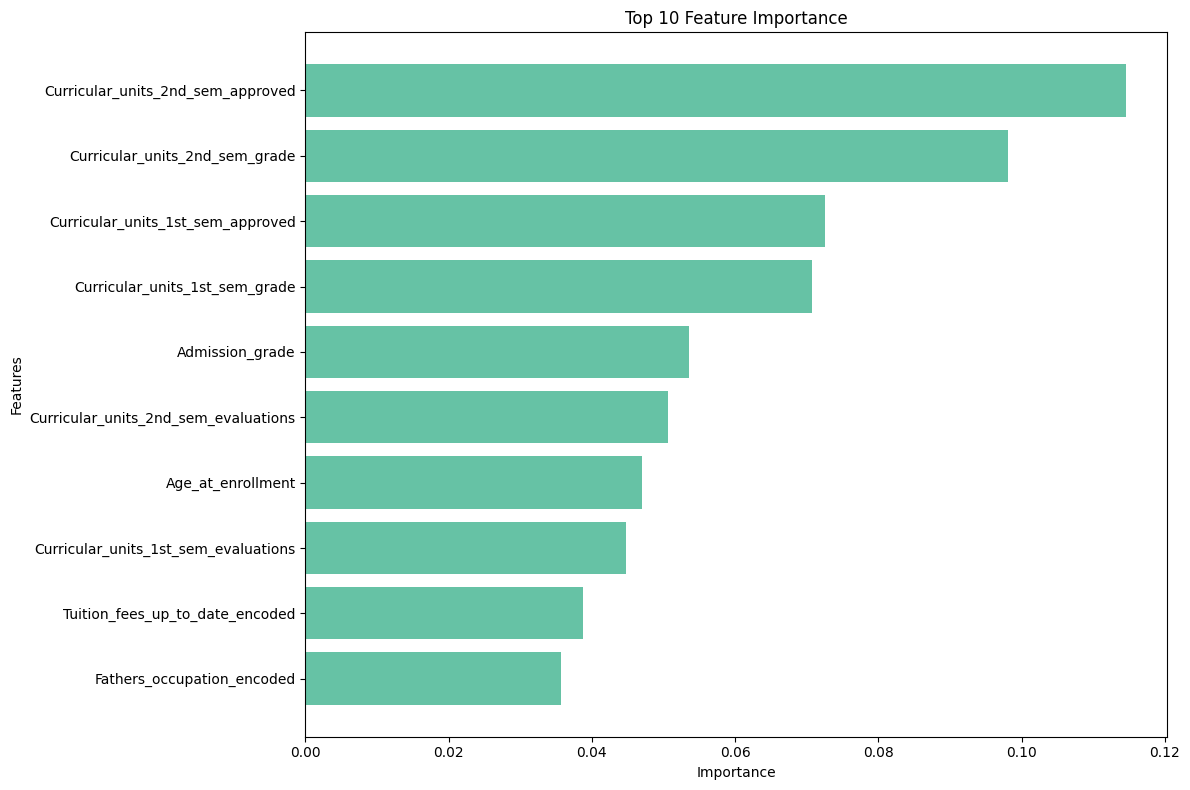

In [12]:
# Visualisasi Feature Importance
plt.figure(figsize=(12, 8))
top_10 = feature_importance.head(10)
plt.barh(range(len(top_10)), top_10['importance'].values)
plt.yticks(range(len(top_10)), top_10['feature'].values)
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Top 10 Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

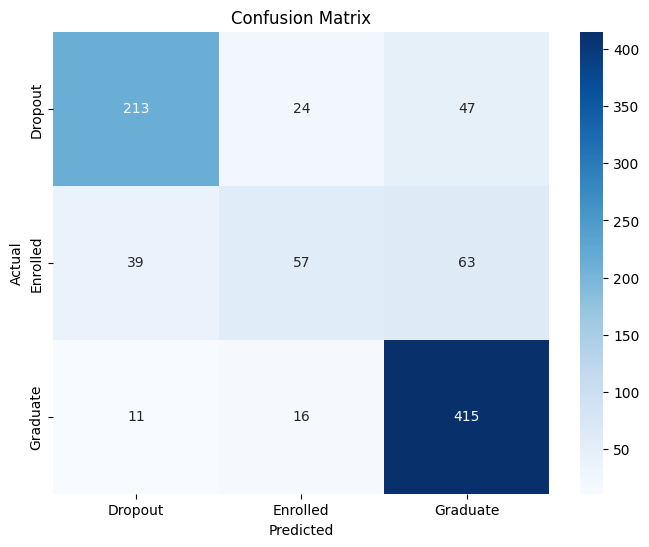

In [13]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Dropout', 'Enrolled', 'Graduate'], yticklabels=['Dropout', 'Enrolled', 'Graduate'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### 4. Conclusion

Dari hasil pelatihan machine learning dan analisis Exploratory Data Analysis (EDA), dapat disimpulkan bahwa:

1. **Faktor Akademik Dominan**: Nilai akademis siswa, terutama pada semester kedua (approved dan grade), merupakan prediktor terkuat untuk status siswa.

2. **Faktor Administratif**: Status biaya kuliah (tuition_fees_up_to_date), beasiswa (scholarship_holder), dan admission grade memiliki pengaruh signifikan.

3. **Faktor Demografis**: Usia saat enrollment dan status internasional juga mempengaruhi kelangsungan studi siswa.

4. **Faktor Ekonomi**: Tingkat pengangguran dan inflasi di lingkungan siswa berpengaruh terhadap kemampuan mereka menyelesaikan studi.

### Rekomendasi Action Items

Berdasarkan hasil analisis, berikut adalah rekomendasi untuk Jaya Jaya Institut:

1. **Intervensi Akademik Dini**: Identifikasi siswa dengan nilai rendah pada semester pertama dan berikan bimbingan akademik intensif.

2. **Dukungan Administratif**: Perbaiki sistem pembayaran biaya kuliah dan berikan insentif bagi siswa yang menjaga status pembayaran aktif.

3. **Program Beasiswa**: Perluas program beasiswa bagi siswa berprestasi dan siswa kurang mampu.

4. **Pembimbingan Karier**: Berikan pembimbingan karier sejak awal untuk membantu siswa memahami komitmen yang diperlukan.

5. **Monitoring Real-time**: Implementasikan sistem monitoring untuk staf akademik agar dapat mengidentifikasi siswa berisiko sejak dini.
